## Context

This notebook serves the purpose of reproducing a miniaturized version of a KG RAG

To do so, we will follow the following steps : 
- Find/create a KG
- Vectorize it
- Create a KG interrogation process
- Integrate the retrieved information in the LLM output

In [ ]:
#!pip install networkx matplotlib
#!pip install sentence-transformers node2vec networkx scikit-learn
#!pip install node2vec
#!pip install --upgrade scipy gensim
#!pip install transformers torch sentence-transformers networkx scikit-learn


In [2]:
#Import des bibliothèques 
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize 
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch




/home/pjgouze/anaconda3/envs/mini_kg_rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Find a KG
Here the focus is on the creation of a KG in order to make sure that the extraction is effective, therefore the KG must be quite small for tests

In [5]:
# dossier de sauvegarde des données 
dossier_data = "Data"
os.makedirs(dossier_data, exist_ok=True)

# Chemin complet pour le fichier
chemin_graphe = os.path.join(dossier_data, "graphe_medical.pkl")

# Créer un graphe orienté pour les relations causales
G = nx.DiGraph()

# Ajouter des nœuds avec des attributs
G.add_node("Diabète de type 2", type="Maladie", gravité="élevée", prévalence="10%")
G.add_node("Résistance à l'insuline", type="Cause", description="Diminution de la sensibilité des cellules à l'insuline")
G.add_node("Soif excessive", type="Symptôme")
G.add_node("Fatigue", type="Symptôme")
G.add_node("Metformine", type="Traitement", type_médicament="antidiabétique")
G.add_node("Régime alimentaire", type="Traitement", type_médicament="non-médicamenteux")
G.add_node("Exercice physique", type="Traitement", type_médicament="non-médicamenteux")
G.add_node("Surpoids", type="Facteur de risque")
G.add_node("Sédentarité", type="Facteur de risque")
G.add_node("Pancréas", type="Organe")
G.add_node("Cœur", type="Organe")

# Ajouter des relations avec des attributs
G.add_edge("Résistance à l'insuline", "Diabète de type 2", relation="CAUSE")
G.add_edge("Diabète de type 2", "Pancréas", relation="AFFECTE")
G.add_edge("Diabète de type 2", "Soif excessive", relation="SYMPTOME")
G.add_edge("Diabète de type 2", "Fatigue", relation="SYMPTOME")
G.add_edge("Diabète de type 2", "Metformine", relation="TRAITE_PAR")
G.add_edge("Diabète de type 2", "Régime alimentaire", relation="TRAITE_PAR")
G.add_edge("Diabète de type 2", "Exercice physique", relation="TRAITE_PAR")
G.add_edge("Surpoids", "Diabète de type 2", relation="RISQUE")
G.add_edge("Sédentarité", "Diabète de type 2", relation="RISQUE")
G.add_edge("Hypertension artérielle", "Cœur", relation="AFFECTE_ORGANE", gravité="moyenne")

# Sauvegarder le graphe
#nx.write_gpickle(G, chemin_graphe)

#print(f"Graphe sauvegardé dans : {chemin_graphe}")

In [4]:
G = nx.DiGraph()

    # =========================
    # 1. Nodes (STRUCTURED)
    # =========================
nodes = {
        "Sepsis": {
            "description": "Life-threatening condition caused by infection leading to organ dysfunction",
            "type": "disease",
            "synonyms": ["septic condition", "systemic infection"]
        },
        "Infection": {
            "description": "Invasion of the body by pathogenic microorganisms",
            "type": "condition",
            "synonyms": ["pathogen invasion"]
        },
        "Bacteria": {
            "description": "Microscopic organisms that can cause infections",
            "type": "pathogen",
            "synonyms": ["bacterial agent"]
        },
        "Fever": {
            "description": "Elevated body temperature, often due to infection",
            "type": "symptom",
            "synonyms": ["high temperature"]
        },
        "Hypotension": {
            "description": "Low blood pressure, common in sepsis and septic shock",
            "type": "symptom",
            "synonyms": ["low blood pressure"]
        },
        "Tachycardia": {
            "description": "Abnormally fast heart rate, often seen in infection",
            "type": "symptom",
            "synonyms": ["high heart rate"]
        },
        "Organ Failure": {
            "description": "Loss of function of one or more organs",
            "type": "condition",
            "synonyms": ["organ dysfunction"]
        },
        "Septic Shock": {
            "description": "Severe sepsis with persistent hypotension and organ failure",
            "type": "disease",
            "synonyms": ["shock due to sepsis"]
        },
        "Severe Hypotension": {
            "description": "Critically low blood pressure requiring intervention",
            "type": "symptom",
            "synonyms": []
        },
        "Multi-Organ Failure": {
            "description": "Failure of multiple organ systems",
            "type": "condition",
            "synonyms": []
        },
        "Bloodstream": {
            "description": "Circulatory system transporting blood",
            "type": "anatomy",
            "synonyms": []
        },
        "Immune Response": {
            "description": "Body defense mechanism against pathogens",
            "type": "process",
            "synonyms": ["immune reaction"]
        },
        "Inflammation": {
            "description": "Biological response to harmful stimuli",
            "type": "process",
            "synonyms": []
        },
        "Organ Dysfunction": {
            "description": "Impaired organ function",
            "type": "condition",
            "synonyms": []
        },
        "Antibiotics": {
            "description": "Drugs used to treat bacterial infections",
            "type": "treatment",
            "synonyms": []
        },
        "Fluid Resuscitation": {
            "description": "Administration of fluids to restore blood volume",
            "type": "treatment",
            "synonyms": []
        },
        "ICU": {
            "description": "Intensive care unit for critically ill patients",
            "type": "location",
            "synonyms": ["intensive care"]
        },
        "Lactate": {
            "description": "Biomarker indicating severity of sepsis and tissue hypoxia",
            "type": "biomarker",
            "synonyms": []
        },
        "Blood Culture": {
            "description": "Test used to detect bacteria in blood",
            "type": "test",
            "synonyms": []
        },
        "SOFA Score": {
            "description": "Clinical score assessing organ failure in sepsis",
            "type": "score",
            "synonyms": []
        },
        "Sepsis Severity": {
            "description": "Degree of severity of sepsis",
            "type": "concept",
            "synonyms": []
        },
    }

for node, attributes in nodes.items():
        G.add_node(node, **attributes)

    # =========================
    # 2. Edges
    # =========================
edges = [
        ("Sepsis", "Infection", "caused_by"),
        ("Sepsis", "Bacteria", "often_caused_by"),
        ("Sepsis", "Fever", "has_symptom"),
        ("Sepsis", "Hypotension", "has_symptom"),
        ("Sepsis", "Tachycardia", "has_symptom"),
        ("Sepsis", "Organ Failure", "can_lead_to"),
        ("Sepsis", "Septic Shock", "can_progress_to"),

        ("Septic Shock", "Sepsis", "is_a"),
        ("Septic Shock", "Severe Hypotension", "characterized_by"),
        ("Septic Shock", "Multi-Organ Failure", "can_lead_to"),

        ("Bacteria", "Bloodstream", "can_infect"),
        ("Infection", "Immune Response", "triggers"),
        ("Immune Response", "Inflammation", "causes"),
        ("Inflammation", "Organ Dysfunction", "can_lead_to"),

        ("Sepsis", "Antibiotics", "treated_with"),
        ("Sepsis", "Fluid Resuscitation", "treated_with"),
        ("Sepsis", "ICU", "managed_in"),

        ("Lactate", "Sepsis", "biomarker_of"),
        ("Blood Culture", "Bacteria", "detects"),
        ("SOFA Score", "Sepsis Severity", "assesses"),
    ]

for source, target, relation in edges:
        G.add_edge(source, target, relation=relation)



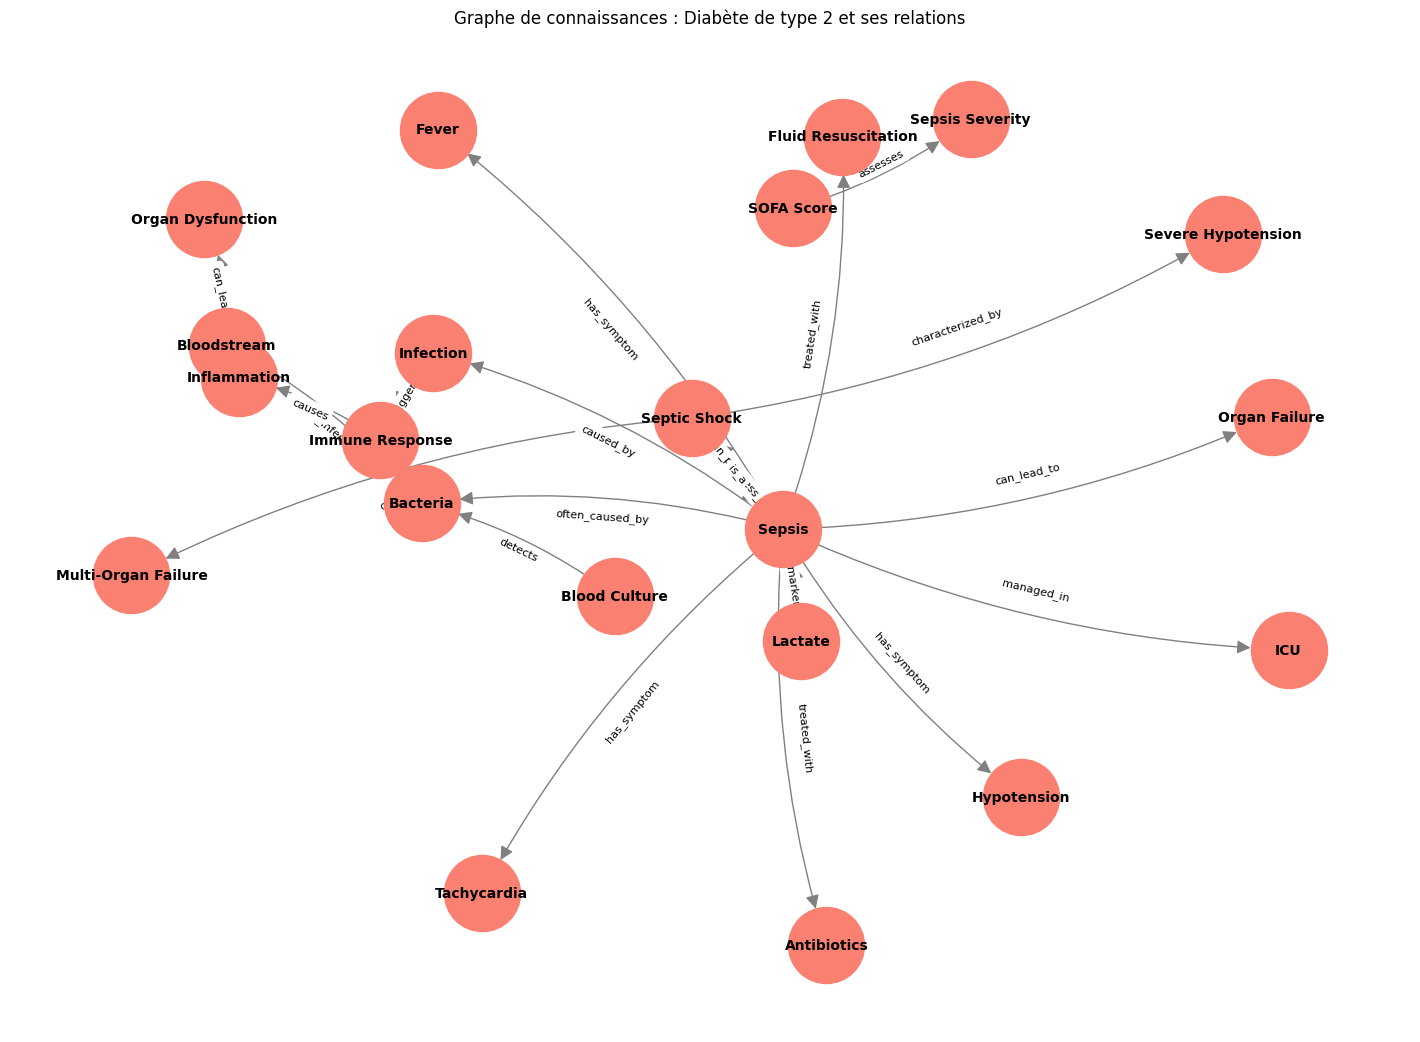

In [5]:
# Visualitation du graphe

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5)  # k pour espacer les nœuds
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="salmon",
        font_size=10, font_weight="bold", edge_color="gray",
        connectionstyle="arc3,rad=0.1", arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Graphe de connaissances : Diabète de type 2 et ses relations")
plt.show()


# Vectorising the KG to create DB


In [10]:
# Extraire les descriptions des nœuds
descriptions = []
for node, attr in G.nodes(data=True):
    description = f"Nœud: {node}. Type: {attr.get('type', 'inconnu')}. "
    if 'gravité' in attr:
        description += f"Gravité: {attr['gravité']}. "
    if 'prévalence' in attr:
        description += f"Prévalence: {attr['prévalence']}. "
    if 'description' in attr:
        description += f"Description: {attr['description']}. "
    descriptions.append(description)

print("Exemple de descriptions :")
print(descriptions[3])

Exemple de descriptions :
Nœud: Fatigue. Type: Symptôme. 


In [8]:
# Charger un modèle de embedding (ex: 'all-MiniLM-L6-v2' pour 384 dimensions)
SentenceTransformer = SentenceTransformer('all-MiniLM-L6-v2')

# Générer les embeddings
embeddings = SentenceTransformer.encode(descriptions, convert_to_tensor=True)

print(f"Embeddings générés pour {len(descriptions)} nœuds.")
print(f"Dimension des embeddings : {embeddings.shape[1]}")


Embeddings générés pour 12 nœuds.
Dimension des embeddings : 384


In [9]:
# Convertir en numpy array et sauvegarder
embeddings_np = embeddings.cpu().numpy()
np.save("embeddings_noeuds.npy", embeddings_np)

# Sauvegarder les IDs des nœuds (pour faire le lien entre embeddings et nœuds)
with open("ids_noeuds.txt", "w") as f:
    f.write("\n".join(G.nodes()))

print("Embeddings et IDs sauvegardés !")


Embeddings et IDs sauvegardés !


# KG RAG prototype
First step : 
Create embedding of the query to make a query in the KG

In [27]:
# Exemple : Rechercher des nœuds similaires à "Diabète de type 2"
query = "Diabète de type 2"
query_embedding = SentenceTransformer.encode(query)

# Calculer la similarité cosinus avec tous les nœuds
similarities = cosine_similarity([query_embedding], embeddings_np)[0]

# Trouver les top 3 nœuds les plus similaires
top_indices = np.argsort(similarities)[::-1][:3]
top_nodes = [list(G.nodes())[i] for i in top_indices]
top_scores = [similarities[i] for i in top_indices]

print("Top 3 nœuds similaires à 'Diabète de type 2' :")
for node, score in zip(top_nodes, top_scores):
    print(f"- {node} (similarité: {score:.2f})")


Top 3 nœuds similaires à 'Diabète de type 2' :
- Diabète de type 2 (similarité: 0.70)
- Résistance à l'insuline (similarité: 0.51)
- Hypertension artérielle (similarité: 0.37)


In [28]:

# Exemple : extraire les voisins du nœud "Diabète de type 2"
nœud_cible = "Diabète de type 2"
voisins_directs = list(G.neighbors(nœud_cible))

print(f"Voisins directs de '{nœud_cible}': {voisins_directs}")


Voisins directs de 'Diabète de type 2': ['Pancréas', 'Soif excessive', 'Fatigue', 'Metformine', 'Régime alimentaire', 'Exercice physique']


In [29]:
# Charger les embeddings et les IDs
embeddings = np.load("embeddings_noeuds.npy")
with open("ids_noeuds.txt", "r") as f:
    nodes = f.read().splitlines()

# Charger le modèle pour encoder la description du nœud sélectionné
model = SentenceTransformer('all-MiniLM-L6-v2')

# Description personnalisée pour le nœud sélectionné
description_cible = f"""
Nœud: {nœud_cible}. Type: {G.nodes[nœud_cible].get('type', 'inconnu')}.
"""
if 'gravité' in G.nodes[nœud_cible]:
    description_cible += f"Gravité: {G.nodes[nœud_cible]['gravité']}. "
if 'prévalence' in G.nodes[nœud_cible]:
    description_cible += f"Prévalence: {G.nodes[nœud_cible]['prévalence']}. "

# Encoder la description
embedding_cible = model.encode(description_cible)


# Calculer la similarité cosinus avec tous les nœuds
similarities = cosine_similarity([embedding_cible], embeddings)[0]

# Trouver les top 5 nœuds les plus similaires
top_indices = np.argsort(similarities)[::-1][:5]
top_nodes_similarité = [nodes[i] for i in top_indices]
top_scores = [similarities[i] for i in top_indices]

print("Top 5 nœuds sémantiquement proches :")
for node, score in zip(top_nodes_similarité, top_scores):
    print(f"- {node} (similarité: {score:.2f})")


AttributeError: 'str' object has no attribute 'items'

In [ ]:
# 1. Voisins directs (structure du graphe)
voisins_directs = set(G.neighbors(nœud_cible))

# 2. Nœuds sémantiquement proches (via embeddings)
top_nodes_similarité = [nodes[i] for i in np.argsort(similarities)[::-1][:10]]

# 3. Fusionner les deux listes et supprimer les doublons
voisins_combinés = list(voisins_directs.union(set(top_nodes_similarité)))

print(f"Voisins combinés (directs + sémantiques) pour '{nœud_cible}':")
for node in voisins_combinés:
    print(f"- {node}")


Voisins combinés (directs + sémantiques) pour 'Diabète de type 2':
- Diabète de type 2
- Pancréas
- Sédentarité
- Régime alimentaire
- Fatigue
- Résistance à l'insuline
- Hypertension artérielle
- Soif excessive
- Metformine
- Exercice physique


# KG RAG With TinyLlama

In [ ]:


# Charger le tokenizer et le modèle
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cpu")

print("Modèle TinyLlama chargé avec succès !")


In [1]:
# 1. Charger le graphe et les embeddings
embeddings = np.load("Data/embeddings_noeuds.npy")
with open("Data/ids_noeuds.txt", "r") as f:
    nodes = f.read().splitlines()
model_embeddings = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Sélectionner un nœud cible, pour le test 
nœud_cible = "Diabète de type 2"

# 3. Extraire les voisins directs
voisins_directs = set(G.neighbors(nœud_cible))

# 4. Trouver les nœuds sémantiquement proches
description_cible = f"Nœud: {nœud_cible}. Type: {G.nodes[nœud_cible].get('type', 'inconnu')}."
embedding_cible = model_embeddings.encode(description_cible)
similarities = cosine_similarity([embedding_cible], embeddings)[0]
top_indices = np.argsort(similarities)[::-1][:10]
top_nodes_similarité = [nodes[i] for i in top_indices]

# 5. Combiner voisins directs et sémantiques
voisins_combinés = list(voisins_directs.union(set(top_nodes_similarité)))

# 6. Construire le contexte
contexte = []
for node in voisins_combinés:
    attrs = G.nodes[node]
    contexte.append(
        f"Nœud: {node}\n"
        f"Type: {attrs.get('type', 'inconnu')}\n"
        f"Description: {attrs.get('description', '')}\n"
    )
contexte_str = "\n".join(contexte)

# Préparer le prompt pour TinyLlama
prompt = f"""
<|system|>
Tu es un assistant médical expert travaillant sur des données extraites d'un graphe de connaissances médical.
Tu dois répondre de manière claire, concise et factuelle aux questions sur les maladies, symptômes et traitements.
</s>
<|user|>
Voici les informations pertinentes extraites du graphe :
{contexte_str}

Réponds à la question suivante :
"Quels sont les symptômes du diabète ?"
</s>
<|assistant|>
"""

# Tokenizer le prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)

# Générer la réponse
outputs = model.generate(input_ids, max_new_tokens=200, do_sample=True, temperature=0.7)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Réponse de TinyLlama :")
print(response)



NameError: name 'np' is not defined

In [50]:
prompt_temoin = f"""
<|system|>
Tu es un assistant médical expert travaillant sur des données extraites d'un graphe de connaissances médical.
Tu dois répondre de manière claire, concise et factuelle aux questions sur les maladies, symptômes et traitements.
</s>
<|user|>

Réponds à la question suivante :
"Quels sont les symptômes du diabète ?"
</s>
<|assistant|>
"""
# Tokenizer le prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)

# Générer la réponse
outputs = model.generate(input_ids, max_new_tokens=200, do_sample=True, temperature=0.7)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Réponse de TinyLlama :")
print(response)


KeyboardInterrupt: 

## Try n°3 : sepsis specific KG

This part is independant from the above, except from the libraries imports

In [ ]:
#pip install langchain langchain-community neo4j elasticsearch transformers
#!pip install faiss-cpu  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 19.7 MB/s eta 0:00:0000:0100:01


In [2]:


# Créer un graphe NetworkX (orienté, car les relations ont un sens)
G_sepsis = nx.DiGraph()

# Ajouter des nœuds avec des propriétés textuelles
G_sepsis.add_node("Patient1", type="Patient", age=65, symptomes=["fièvre", "tachycardie", "hypotension"])
G_sepsis.add_node("Patient2", type="Patient", age=45, symptomes=["fièvre", "frissons"])
G_sepsis.add_node("Patient3", type="Patient", age=30, symptomes=["tachycardie", "hypotension", "confusion"])

# Diagnostics et traitements uniques (pour éviter les doublons)
G_sepsis.add_node("Sepsis1", type="Diagnostic", description="Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)")
G_sepsis.add_node("Sepsis2", type="Diagnostic", description="Sepsis non sévère (score qSOFA = 1)")
G_sepsis.add_node("TraitementSevere", type="Traitement", description="Antibiothérapie IV large spectre, remplissage vasculaire")
G_sepsis.add_node("TraitementNonSevere", type="Traitement", description="Antibiothérapie per os, surveillance")

# Signes uniques
G_sepsis.add_node("SigneFièvre", type="Signe", description="Fièvre (> 38°C)")
G_sepsis.add_node("SigneFrissons", type="Signe", description="Frissons")
G_sepsis.add_node("SigneConfusion", type="Signe", description="Confusion ou altération de l'état mental")
G_sepsis.add_node("SigneTachycardie", type="Signe", description="Tachycardie (> 100 bpm)")
G_sepsis.add_node("SigneHypotension", type="Signe", description="Hypotension (PA systolique < 100 mmHg)")

# Ajouter des arêtes (relations) pour chaque patient
G_sepsis.add_edge("Patient1", "Sepsis1", relation="A_POUR_DIAGNOSTIC")
G_sepsis.add_edge("Patient1", "SigneFièvre", relation="PRESENTE")
G_sepsis.add_edge("Patient1", "SigneTachycardie", relation="PRESENTE")
G_sepsis.add_edge("Patient1", "SigneHypotension", relation="PRESENTE")
G_sepsis.add_edge("Sepsis1", "TraitementSevere", relation="A_POUR_TRAITEMENT")

G_sepsis.add_edge("Patient2", "Sepsis2", relation="A_POUR_DIAGNOSTIC")
G_sepsis.add_edge("Patient2", "SigneFièvre", relation="PRESENTE")
G_sepsis.add_edge("Patient2", "SigneFrissons", relation="PRESENTE")
G_sepsis.add_edge("Sepsis2", "TraitementNonSevere", relation="A_POUR_TRAITEMENT")

G_sepsis.add_edge("Patient3", "Sepsis1", relation="A_POUR_DIAGNOSTIC")
G_sepsis.add_edge("Patient3", "SigneTachycardie", relation="PRESENTE")
G_sepsis.add_edge("Patient3", "SigneHypotension", relation="PRESENTE")
G_sepsis.add_edge("Patient3", "SigneConfusion", relation="PRESENTE")
G_sepsis.add_edge("Sepsis1", "TraitementSevere", relation="A_POUR_TRAITEMENT")

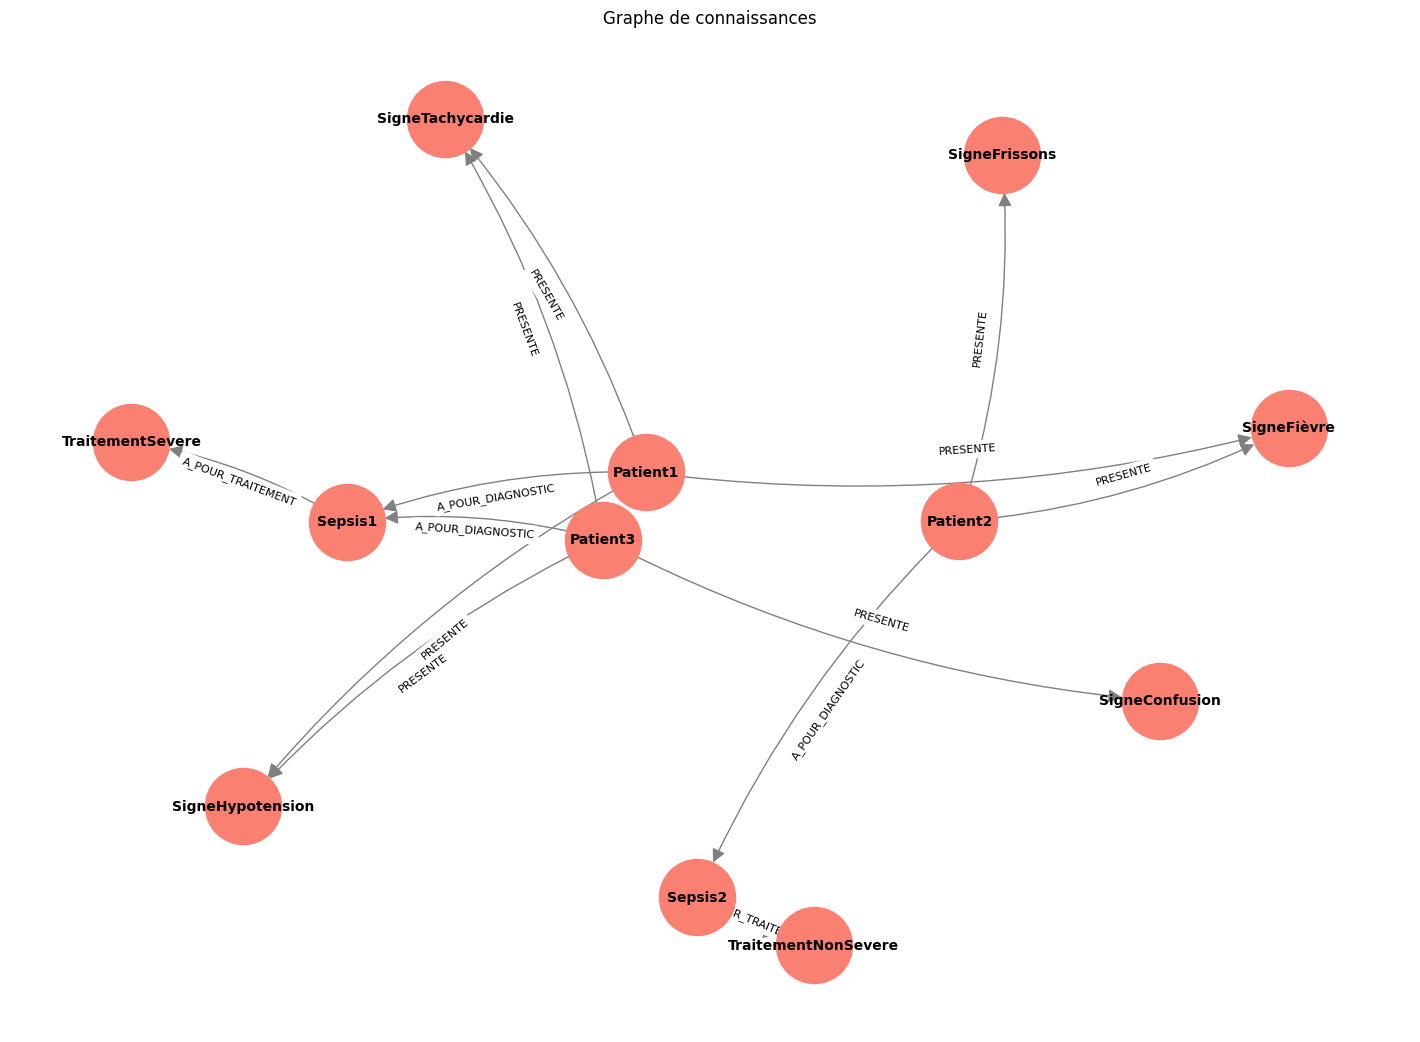

In [3]:
#Visualisation du graphe
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_sepsis, k=0.5)  # k pour espacer les nœuds
nx.draw(G_sepsis, pos, with_labels=True, node_size=3000, node_color="salmon",
        font_size=10, font_weight="bold", edge_color="gray",
        connectionstyle="arc3,rad=0.1",arrowsize=20)
edge_labels = nx.get_edge_attributes(G_sepsis, 'relation')
nx.draw_networkx_edge_labels(G_sepsis, pos, edge_labels=edge_labels, font_size=8)
plt.title("Graphe de connaissances")
plt.show()

In [4]:
nodes = []
for node, data in G_sepsis.nodes(data=True):
    # Créer un texte descriptif pour chaque nœud
    text = f"Nœud {node} ({data.get('type', 'Inconnu')}) : "
    for key, value in data.items():
        if key != "type":
            text += f"{key} = {value}, "
    text = text.rstrip(", ")
    nodes.append({"id": node, "text": text, "type": data.get("type")})

# Afficher les nœuds extraits
print("Nœuds extraits :")
for node in nodes:
    print(node)

Nœuds extraits :
{'id': 'Patient1', 'text': "Nœud Patient1 (Patient) : age = 65, symptomes = ['fièvre', 'tachycardie', 'hypotension']", 'type': 'Patient'}
{'id': 'Patient2', 'text': "Nœud Patient2 (Patient) : age = 45, symptomes = ['fièvre', 'frissons']", 'type': 'Patient'}
{'id': 'Patient3', 'text': "Nœud Patient3 (Patient) : age = 30, symptomes = ['tachycardie', 'hypotension', 'confusion']", 'type': 'Patient'}
{'id': 'Sepsis1', 'text': 'Nœud Sepsis1 (Diagnostic) : description = Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)', 'type': 'Diagnostic'}
{'id': 'Sepsis2', 'text': 'Nœud Sepsis2 (Diagnostic) : description = Sepsis non sévère (score qSOFA = 1)', 'type': 'Diagnostic'}
{'id': 'TraitementSevere', 'text': 'Nœud TraitementSevere (Traitement) : description = Antibiothérapie IV large spectre, remplissage vasculaire', 'type': 'Traitement'}
{'id': 'TraitementNonSevere', 'text': 'Nœud TraitementNonSevere (Traitement) : description = Antibiothérapie per os, surveillance', 'type': 'T

In [5]:
from transformers import AutoTokenizer, AutoModel
import torch

# Charger BioBERT
model_name = "monologg/biobert_v1.1_pubmed"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def embed_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Embedding des nœuds
for node in nodes:
    node["embedding"] = embed_text(node["text"])

# Exemple d'embedding pour un nœud
print("Embedding du nœud 'Patient1':", nodes[0]["embedding"][:10])  # Affiche les 10 premières valeurs

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8315.90it/s]
BertModel LOAD REPORT from: monologg/biobert_v1.1_pubmed
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding du nœud 'Patient1': [ 0.07233633  0.10756446  0.00072375  0.02207527 -0.06595485  0.14203928
 -0.08791524  0.09267393  0.0595792   0.04443539]


In [6]:
import numpy as np
import faiss

# Préparer les embeddings pour FAISS
embeddings = np.array([node["embedding"] for node in nodes]).astype('float32')

# Créer un index FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

# Sauvegarder l'index (optionnel)
faiss.write_index(index, "kg_embeddings_networkx.index")

In [7]:
model_name_llm = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer_llm = AutoTokenizer.from_pretrained(model_name_llm)
model_llm = AutoModelForCausalLM.from_pretrained(model_name_llm, dtype=torch.float32).to("cpu")

def generate_response(context, query):
    prompt = f"""
    Contexte :
    Tu es un expert en biomédical. Réponds de manière concise et médicale, en citant les informations pertinentes du contexte.
    Question : {query}

    Et voici le context : {context}

    """

    inputs = tokenizer_llm(prompt, return_tensors="pt").to("cpu")
    outputs = model_llm.generate(**inputs, max_new_tokens=200, do_sample=True, temperature=0.001)
    return tokenizer_llm.decode(outputs[0], skip_special_tokens=True)


def rag_pipeline(query, k=3, threshold=0.6):
    # --- 1. Embedding de la requête ---
    query_embedding = embed_text(query)
    query_embedding = query_embedding / np.linalg.norm(query_embedding)  # Normalisation L2

    # --- 2. Charger l'index FAISS existant ---
    # (Ton index est déjà créé avec IndexFlatL2, mais on va normaliser les embeddings pour comparer)
    index = faiss.read_index("kg_embeddings_networkx.index")  # Charger ton index existant

    # --- 3. Normaliser les embeddings du KG (pour comparer des vecteurs unitaires) ---
    # Note : Si tu as déjà normalisé lors de la création de l'index, cette étape est redondante.
    # Sinon, normalize les embeddings avant de les comparer.  ### Voir ce que ça fait quand on ne normalise pas
    embeddings_normalized = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

    # --- 4. Recherche de similarité ---
    # Convertir la requête en vecteur normalisé
    query_normalized = query_embedding.reshape(1, -1).astype('float32')

    # Recherche de similarité (distance L2 entre vecteurs normalisés = similarité cosinus)
    distances, indices = index.search(query_normalized, k + 1)

    # --- 5. Filtrer les nœuds pertinents ---
    # On utilise les distances L2 des vecteurs normalisés (équivalent à 1 - similarité cosinus)
    # Plus la distance est proche de 0, plus la similarité est forte.
    relevant_indices = []
    for i, dist in zip(indices[0], distances[0]):
        if dist < 1-threshold:  # Seuil ajusté pour L2 (distance proche de 0 = similaire)
            relevant_indices.append(i)

    # Si aucun nœud ne dépasse le seuil, prendre les k premiers
    if not relevant_indices:
        relevant_indices = indices[0][:k]
        print("⚠️ Aucun nœud ne dépasse le seuil de similarité. Prise des k premiers nœuds.")

    relevant_nodes = [nodes[i] for i in relevant_indices[:k]]

    # --- 6. Logging pour le debug ---
    print(f"Requête : {query}")
    print(f"Indices des nœuds retrouvés : {indices[0]}")
    print(f"Distances L2 (normalisées) : {distances[0]}")
    print(f"Nœuds sélectionnés : {[nodes[i]['id'] for i in relevant_indices[:k]]}")

    # --- 7. Génération de la réponse ---
    context = "\n".join([node["text"] for node in relevant_nodes])
    response = generate_response(context, query)

    return response, relevant_nodes

# Test
query = "Un patient de 65 ans a de la fièvre et une hypotension. Quel est son diagnostic ?"
response, nodes_used = rag_pipeline(query, threshold=0.8)
print("\nRéponse générée :", response)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 306.10it/s]
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


⚠️ Aucun nœud ne dépasse le seuil de similarité. Prise des k premiers nœuds.
Requête : Un patient de 65 ans a de la fièvre et une hypotension. Quel est son diagnostic ?
Indices des nœuds retrouvés : [ 3  5 11  0]
Distances L2 (normalisées) : [89.273926 92.261635 93.23727  94.046104]
Nœuds sélectionnés : ['Sepsis1', 'TraitementSevere', 'SigneHypotension']

Réponse générée : 
    Contexte :
    Tu es un expert en biomédical. Réponds de manière concise et médicale, en citant les informations pertinentes du contexte.
    Question : Un patient de 65 ans a de la fièvre et une hypotension. Quel est son diagnostic ?

    Et voici le context : Nœud Sepsis1 (Diagnostic) : description = Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)
Nœud TraitementSevere (Traitement) : description = Antibiothérapie IV large spectre, remplissage vasculaire
Nœud SigneHypotension (Signe) : description = Hypotension (PA systolique < 100 mmHg)

    
    Résumé :
    Le patient est un homme de 65 ans, ayant une hy

## Decomposing in function to debugg

In [ ]:
import numpy as np
import faiss
from sklearn.preprocessing import normalize

# --- Fonctions utilitaires ---

def embed_text(text, model_biobert, tokenizer_biobert):
    """
    Embedde un texte avec BioBERT et retourne un vecteur numpy.

    Args:
        text (str): Texte à embedder.
        model_biobert: Modèle BioBERT chargé.
        tokenizer_biobert: Tokenizer BioBERT chargé.

    Returns:
        np.ndarray: Embedding normalisé (vecteur de taille `dimension`).
    """
    inputs = tokenizer_biobert(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model_biobert(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embedding / np.linalg.norm(embedding)  # Normalisation L2

def load_faiss_index(index_path):
    """
    Charge un index FAISS depuis un fichier.

    Args:
        index_path (str): Chemin vers le fichier de l'index FAISS.

    Returns:
        faiss.Index: Index FAISS chargé.
    """
    print("nombre d'index :", len(index_path))
    return faiss.read_index(index_path)

def search_nodes(index, query_embedding, k=3):
    """
    Recherche les `k` nœuds les plus similaires dans l'index FAISS.

    Args:
        index (faiss.Index): Index FAISS chargé.
        query_embedding (np.ndarray): Embedding de la requête (vecteur normalisé).
        k (int): Nombre de résultats à retourner.

    Returns:
        tuple: (distances, indices) des nœuds retrouvés.
    """
    query_normalized = query_embedding.reshape(1, -1).astype('float32')
    return in²dex.search(query_normalized, k)

def filter_nodes_by_similarity(indices, distances, nodes, threshold=0.6):
    """
    Filtre les nœuds pertinents en fonction d'un seuil de similarité.

    Args:
        indices (np.ndarray): Indices des nœuds retrouvés.
        distances (np.ndarray): Distances L2 (normalisées) des nœuds.
        nodes (list): Liste des nœuds du KG.
        threshold (float): Seuil de similarité (0 à 1). Plus le seuil est haut, plus la sélection est stricte.

    Returns:
        list: Nœuds filtrés (au maximum `k`).
    """
    relevant_indices = [i for i, dist in zip(indices, distances) if dist < 1 - threshold]
    if not relevant_indices:
        relevant_indices = indices[:len(nodes)]  # Fallback : prend tous les nœuds si aucun ne dépasse le seuil
        print("⚠️ Aucun nœud ne dépasse le seuil de similarité. Prise de tous les nœuds.")
    return [nodes[i] for i in relevant_indices]

def generate_response_llm(context, query, model_llm, tokenizer_llm):
    """
    Génère une réponse avec un LLM (TinyLlama) en utilisant le contexte.

    Args:
        context (str): Contexte extrait du KG.
        query (str): Requête utilisateur.
        model_llm: Modèle TinyLlama chargé.
        tokenizer_llm: Tokenizer TinyLlama chargé.

    Returns:
        str: Réponse générée.
    """
    prompt = f"""
    Tu es un expert du biomédical. Réponds de manière concise et médicale, en citant les informations pertinentes du contexte.

    Contexte :
    {context}

    Question : {query}

    """

    inputs = tokenizer_llm(prompt, return_tensors="pt").to("cuda" if torch.cuda.is_available() else "cpu")
    outputs = model_llm.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.3,
        pad_token_id=tokenizer_llm.eos_token_id
    )
    return tokenizer_llm.decode(outputs[0], skip_special_tokens=True)

def rag_pipeline(query, k=3, threshold=0.6, index_path=None, nodes=None, model_biobert=None, tokenizer_biobert=None, model_llm=None, tokenizer_llm=None):
    """
    Pipeline RAG complet : embedding → recherche → filtrage → génération.

    Args:
        query (str): Requête utilisateur.
        k (int): Nombre de nœuds à retourner.
        threshold (float): Seuil de similarité (0 à 1).
        index_path (str): Chemin vers l'index FAISS.
        nodes (list): Liste des nœuds du KG.
        model_biobert: Modèle BioBERT chargé.
        tokenizer_biobert: Tokenizer BioBERT chargé.
        model_llm: Modèle TinyLlama chargé.
        tokenizer_llm: Tokenizer TinyLlama chargé.

    Returns:
        tuple: (réponse, nœuds utilisés)
    """
    if not all([index_path, nodes, model_biobert, tokenizer_biobert, model_llm, tokenizer_llm]):
        raise ValueError("Tous les paramètres (index, nodes, modèles) doivent être fournis.")

    # 1. Embedding de la requête
    query_embedding = embed_text(query, model_biobert, tokenizer_biobert)
    print(f"🔍 Embedding de la requête : {query_embedding[:5]}...")  # Affiche les 5 premières valeurs

    # 2. Chargement de l'index FAISS
    index = load_faiss_index(index_path)
    print(f"📂 Index FAISS chargé depuis {index_path}")

    # 3. Recherche dans l'index
    distances, indices = search_nodes(index, query_embedding, k)
    print(f"🔎 Nœuds retrouvés (indices) : {indices}")
    print(f"📊 Distances L2 (normalisées) : {distances}")

    # 4. Filtrage par seuil de similarité
    relevant_nodes = filter_nodes_by_similarity(indices[0], distances[0], nodes, threshold)
    print(f"✅ Nœuds sélectionnés : {[node['id'] for node in relevant_nodes]}")

    # 5. Génération de la réponse
    context = "\n".join([node["text"] for node in relevant_nodes])
    response = generate_response_llm(context, query, model_llm, tokenizer_llm)

    return response, relevant_nodes

In [20]:
# --- Charger les modèles ---
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import torch

# BioBERT pour l'embedding des noeuds
model_name_biobert = "monologg/biobert_v1.1_pubmed"
tokenizer_biobert = AutoTokenizer.from_pretrained(model_name_biobert)
model_biobert = AutoModel.from_pretrained(model_name_biobert)

# TinyLlama pour l'interaction avec le LLM
model_name_llm = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer_llm = AutoTokenizer.from_pretrained(model_name_llm)
model_llm = AutoModelForCausalLM.from_pretrained(
    model_name_llm,
    torch_dtype=torch.float16,
    device_map="cpu",
)

# --- Exécuter le pipeline ---
response, nodes_used = rag_pipeline(
    query="Un patient de 65 ans a de la fièvre et une hypotension. Quel est son diagnostic ?",
    k=3,
    threshold=0.6,
    index_path="kg_embeddings_networkx.index",
    nodes=nodes,  # Ta liste de nœuds (déjà préparée)
    model_biobert=model_biobert,
    tokenizer_biobert=tokenizer_biobert,
    model_llm=model_llm,
    tokenizer_llm=tokenizer_llm
)

print("\n🎯 Réponse générée :", response)
print("📌 Nœuds utilisés :", [node['id'] for node in nodes_used])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2479.88it/s]
BertModel LOAD REPORT from: monologg/biobert_v1.1_pubmed
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:06<00:00, 30.95it/s]
Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer 

🔍 Embedding de la requête : [-0.01130785  0.01577874 -0.00460072  0.0314637   0.01117966]...
nombre d'index : 28
📂 Index FAISS chargé depuis kg_embeddings_networkx.index
🔎 Nœuds retrouvés (indices) : [[ 3  5 11]]
📊 Distances L2 (normalisées) : [[89.273926 92.261635 93.23727 ]]
⚠️ Aucun nœud ne dépasse le seuil de similarité. Prise de tous les nœuds.
✅ Nœuds sélectionnés : ['Sepsis1', 'TraitementSevere', 'SigneHypotension']

🎯 Réponse générée : 
    Tu es un expert du biomédical. Réponds de manière concise et médicale, en citant les informations pertinentes du contexte.

    Contexte :
    Nœud Sepsis1 (Diagnostic) : description = Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)
Nœud TraitementSevere (Traitement) : description = Antibiothérapie IV large spectre, remplissage vasculaire
Nœud SigneHypotension (Signe) : description = Hypotension (PA systolique < 100 mmHg)

    Question : Un patient de 65 ans a de la fièvre et une hypotension. Quel est son diagnostic ?

    1. Sepsis sévè

In [16]:
response, nodes_used = rag_pipeline(
    query="Un patient de 30 ans a de la fièvre. Quel est son diagnostic ?",
    k=3,
    threshold=0,
    index_path="kg_embeddings_networkx.index",
    nodes=nodes,  # Ta liste de nœuds (déjà préparée)
    model_biobert=model_biobert,
    tokenizer_biobert=tokenizer_biobert,
    model_llm=model_llm,
    tokenizer_llm=tokenizer_llm
)

print("\n🎯 Réponse générée :", response)
print("📌 Nœuds utilisés :", [node['id'] for node in nodes_used])

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔍 Embedding de la requête : [-0.01461701  0.00292268 -0.00407466  0.03145542  0.0183221 ]...
📂 Index FAISS chargé depuis kg_embeddings_networkx.index
🔎 Nœuds retrouvés (indices) : [[ 3  5 11]]
📊 Distances L2 (normalisées) : [[89.89596 92.72409 94.48673]]
⚠️ Aucun nœud ne dépasse le seuil de similarité. Prise de tous les nœuds.
✅ Nœuds sélectionnés : ['Sepsis1', 'TraitementSevere', 'SigneHypotension']

🎯 Réponse générée : 
    Tu es un expert du biomédical. Réponds de manière concise et médicale, en citant les informations pertinentes du contexte.

    Contexte :
    Nœud Sepsis1 (Diagnostic) : description = Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)
Nœud TraitementSevere (Traitement) : description = Antibiothérapie IV large spectre, remplissage vasculaire
Nœud SigneHypotension (Signe) : description = Hypotension (PA systolique < 100 mmHg)

    Question : Un patient de 30 ans a de la fièvre. Quel est son diagnostic ?

    1. Sepsis sévère (score qSOFA ≥ 2, lactate ≥ 2 mmol/L)
 